# Deep Q-Networks (DQN) from Scratch 🧠

## 🧠 Theoretical Background
Deep Q-Networks (DQN) extend Q-Learning by using a Deep Neural Network to approximate the Q-function, allowing it to handle large or continuous state spaces.
- **Experience Replay**: Stores transitions in a buffer and samples them randomly to break correlation between consecutive samples.
- **Target Network**: Uses a separate, slowly updating network to calculate target Q-values, stabilizing training.

In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
import random
import numpy as np
import matplotlib.pyplot as plt
from collections import deque

In [2]:

class GridWorld:
    def __init__(self):
        self.state = 0
    def reset(self):
        self.state = 0
        return self.state
    def step(self, action):
        row, col = divmod(self.state, 4)
        if action == 0: row = max(0, row - 1)    # Up
        elif action == 1: row = min(3, row + 1) # Down
        elif action == 2: col = max(0, col - 1) # Left
        elif action == 3: col = min(3, col + 1) # Right
        self.state = row * 4 + col
        reward = 1 if self.state == 15 else 0
        done = self.state == 15
        return self.state, reward, done


In [3]:

class DQN(nn.Module):
    def __init__(self, state_size, action_size):
        super().__init__()
        self.fc = nn.Sequential(
            nn.Linear(state_size, 24),
            nn.ReLU(),
            nn.Linear(24, 24),
            nn.ReLU(),
            nn.Linear(24, action_size)
        )
    def forward(self, x):
        return self.fc(x)

class DQNAgent:
    def __init__(self, state_size, action_size):
        self.state_size = state_size
        self.action_size = action_size
        self.memory = deque(maxlen=2000)
        self.gamma = 0.95
        self.epsilon = 1.0
        self.epsilon_min = 0.01
        self.epsilon_decay = 0.995
        self.model = DQN(state_size, action_size)
        self.optimizer = optim.Adam(self.model.parameters(), lr=0.001)

    def act(self, state):
        if np.random.rand() <= self.epsilon:
            return random.randrange(self.action_size)
        state_t = torch.FloatTensor(state)
        with torch.no_grad():
            act_values = self.model(state_t)
        return torch.argmax(act_values).item()

    def replay(self, batch_size):
        if len(self.memory) < batch_size: return
        minibatch = random.sample(self.memory, batch_size)
        for state, action, reward, next_state, done in minibatch:
            target = reward
            if not done:
                next_state_t = torch.FloatTensor(next_state)
                target = (reward + self.gamma * torch.max(self.model(next_state_t)).item())
            
            state_t = torch.FloatTensor(state)
            target_f = self.model(state_t)
            target_f = target_f.clone().detach()
            target_f[action] = target
            
            loss = nn.MSELoss()(self.model(state_t), target_f)
            self.optimizer.zero_grad()
            loss.backward()
            self.optimizer.step()
        if self.epsilon > self.epsilon_min:
            self.epsilon *= self.epsilon_decay

# Simulated training on GridWorld encoded as 1D
agent = DQNAgent(16, 4)
env = GridWorld()
dqn_rewards = []
for e in range(50):
    state = np.zeros(16)
    state[env.reset()] = 1.0
    done = False
    total_r = 0
    while not done:
        action = agent.act(state)
        next_s, reward, done = env.step(action)
        next_state = np.zeros(16)
        next_state[next_s] = 1.0
        agent.memory.append((state, action, reward, next_state, done))
        state = next_state
        total_r += reward
    agent.replay(32)
    dqn_rewards.append(total_r)


### 📊 Visualization: DQN Performance

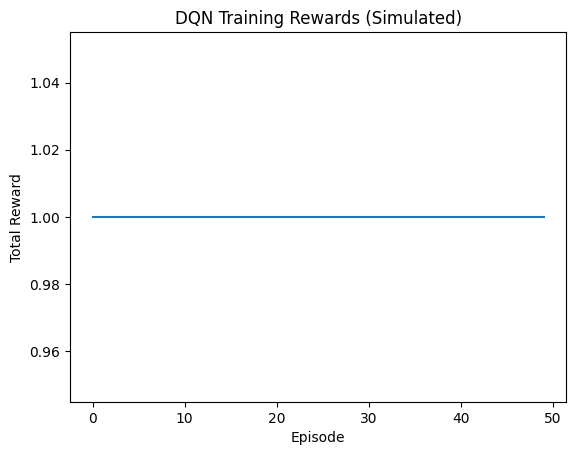

In [4]:
plt.plot(dqn_rewards)
plt.title('DQN Training Rewards (Simulated)')
plt.xlabel('Episode')
plt.ylabel('Total Reward')
plt.show()